# Magnitude vs time — rolling forecast windows

Single explanatory panel. Day 0 = start of the test set (training is negative). Colored bands = forecast windows. ★ = yearly ETAS refit. Bottom ticks = days since test start; top ticks = 1 January.


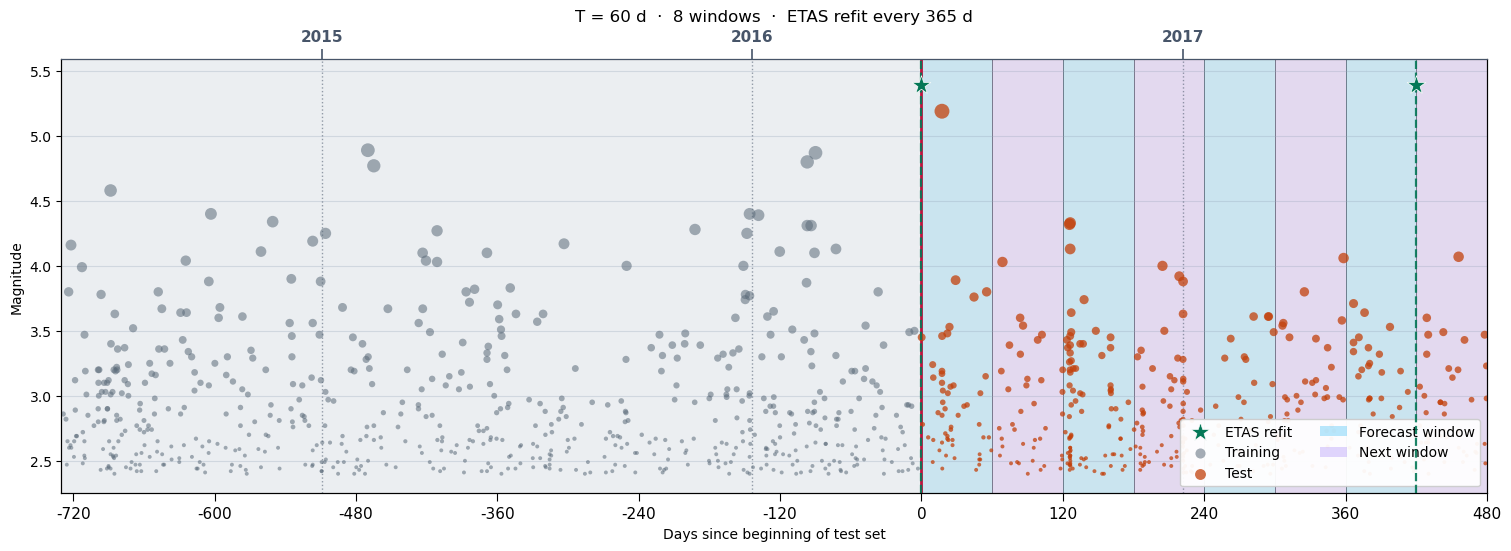

In [1]:
%matplotlib inline
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "runnable_code" / "run_rolling_continuation.py").is_file():
    REPO_ROOT = REPO_ROOT.parent if REPO_ROOT.name == "notebooks" else next(
        parent for parent in REPO_ROOT.parents
        if (parent / "runnable_code" / "run_rolling_continuation.py").is_file()
    )

# ---- knobs ------------------------------------------------------------------
HORIZON_DAYS = 60
N_TEST_WINDOWS: int | None = 8          # None = all windows
TRAIN_LOOKBACK_DAYS: float | None = 365 * 2
INVERSION_INTERVAL_DAYS: float | None = None  # None → config / 365
SAVE_PATH = None  # e.g. REPO_ROOT / "outputs" / "presentation_figs" / "mag_vs_days.png"
# -----------------------------------------------------------------------------

SHORT = HORIZON_DAYS <= 1
ROOT = REPO_ROOT / (
    "outputs/rolling_continuation_hauksson_pre_ridgecrest_short"
    if SHORT else
    "outputs/rolling_continuation_hauksson_pre_ridgecrest"
)
CFG_PATH = REPO_ROOT / (
    "config/rolling_continuation_hauksson_pre_ridgecrest_short.json"
    if SHORT else
    "config/rolling_continuation_hauksson_pre_ridgecrest.json"
)

COLOR_TRAIN, COLOR_TEST = "#5B6B7A", "#C2410C"
COLOR_BAND_A, COLOR_BAND_B = "#38BDF8", "#A78BFA"
COLOR_BOUNDARY, COLOR_DAY0 = "#0F172A", "#BE123C"
COLOR_REFIT, COLOR_YEAR = "#047857", "#475569"

cfg = json.loads(CFG_PATH.read_text(encoding="utf-8"))
mc = float(cfg["mc"])
train_start = pd.to_datetime(cfg["timewindow_start"])
test_start = pd.to_datetime(cfg["timewindow_end"])
catalog_path = REPO_ROOT / cfg["fn_catalog"]
interval_days = float(
    INVERSION_INTERVAL_DAYS
    if INVERSION_INTERVAL_DAYS is not None
    else cfg.get("inversion_interval", 365)
)

raw = pd.read_csv(catalog_path)
raw["time"] = pd.to_datetime(raw["time"], utc=True, format="mixed").dt.tz_convert(None)
raw = raw.loc[raw["magnitude"] >= mc].copy()
raw["days"] = (raw["time"] - test_start) / pd.Timedelta("1D")

plot_train_start = train_start
if TRAIN_LOOKBACK_DAYS is not None:
    plot_train_start = max(
        train_start, test_start - pd.Timedelta(days=float(TRAIN_LOOKBACK_DAYS))
    )

hdir = ROOT / f"horizon_{HORIZON_DAYS:g}d"
windows_all = pd.read_csv(hdir / "rolling_summary.csv")
windows_all["forecast_start"] = pd.to_datetime(windows_all["forecast_start"])
windows_all["forecast_end"] = pd.to_datetime(windows_all["forecast_end"])
windows_all["start_days"] = (
    windows_all["forecast_start"] - test_start
) / pd.Timedelta("1D")
windows_all["end_days"] = (
    windows_all["forecast_end"] - test_start
) / pd.Timedelta("1D")

windows = (
    windows_all if N_TEST_WINDOWS is None
    else windows_all.head(int(N_TEST_WINDOWS))
)
x_min = -float((test_start - plot_train_start) / pd.Timedelta("1D"))
x_max = float(windows["end_days"].iloc[-1])

events = raw.loc[(raw["days"] >= x_min) & (raw["days"] <= x_max)]
train = events.loc[events["days"] < 0]
test = events.loc[events["days"] >= 0]

# ETAS refit times (same rule as rolling_continuation.inversion_anchor_indices)
starts = windows_all["start_days"].to_numpy(dtype=float)
refits = [float(starts[0])]
anchor = refits[0]
for t in starts[1:]:
    if float(t) - anchor > interval_days:
        anchor = float(t)
        refits.append(anchor)
refit_days = np.asarray(
    [d for d in refits if x_min <= d <= x_max], dtype=float
)

# Year starts (1 Jan) in view
t0 = test_start + pd.Timedelta(days=float(x_min))
t1 = test_start + pd.Timedelta(days=float(x_max))
year0 = t0.year if (t0.month == 1 and t0.day == 1) else t0.year + 1
year_days, year_labels = [], []
for y in range(year0, t1.year + 1):
    d = float((pd.Timestamp(y, 1, 1) - test_start) / pd.Timedelta("1D"))
    if x_min <= d <= x_max:
        year_days.append(d)
        year_labels.append(str(y))

fig, ax = plt.subplots(figsize=(15, 5.4), constrained_layout=True)
ax.set_facecolor("#F8FAFC")

ax.axvspan(x_min, 0.0, facecolor=COLOR_TRAIN, alpha=0.08, zorder=0)
ax.axvspan(0.0, x_max, facecolor=COLOR_TEST, alpha=0.06, zorder=0)

for i, row in enumerate(windows.itertuples(index=False)):
    ax.axvspan(
        float(row.start_days), float(row.end_days),
        facecolor=COLOR_BAND_A if i % 2 == 0 else COLOR_BAND_B,
        alpha=0.22, edgecolor="none", zorder=0,
    )
bounds = np.unique(np.concatenate([
    windows["start_days"].to_numpy(float),
    windows["end_days"].to_numpy(float)[-1:],
]))
for x in bounds:
    ax.axvline(x, color=COLOR_BOUNDARY, lw=0.7, alpha=0.5, zorder=1)

ax.axvline(0.0, color=COLOR_DAY0, lw=2.0, zorder=3)

for i, x in enumerate(refit_days):
    ax.axvline(x, color=COLOR_REFIT, lw=1.6, ls="--", alpha=0.9, zorder=6)
    ax.scatter(
        [x], [events["magnitude"].max() + 0.2],
        marker="*", s=200, c=COLOR_REFIT,
        edgecolors="white", linewidths=0.5, zorder=7,
        label="ETAS refit" if i == 0 else None,
    )

def marker_size(mag):
    return np.clip(18.0 * (np.asarray(mag, dtype=float) - mc + 0.4) ** 1.6, 8.0, 220.0)

ax.scatter(
    train["days"], train["magnitude"],
    s=marker_size(train["magnitude"]), c=COLOR_TRAIN,
    alpha=0.55, linewidths=0, zorder=4, label="Training",
)
ax.scatter(
    test["days"], test["magnitude"],
    s=marker_size(test["magnitude"]), c=COLOR_TEST,
    alpha=0.75, linewidths=0, zorder=5, label="Test",
)

ax.set_xlim(x_min, x_max)
ax.set_ylim(events["magnitude"].min() - 0.15, events["magnitude"].max() + 0.4)
ax.set_xlabel("Days since beginning of test set")
ax.set_ylabel("Magnitude")
ax.set_title(
    f"T = {HORIZON_DAYS:g} d  ·  {len(windows)} windows  ·  "
    f"ETAS refit every {interval_days:g} d"
)
ax.grid(True, axis="y", alpha=0.3, color="#94A3B8")

# Bottom axis: day-number ticks (days since test start).
day_step = max(30.0, round((x_max - x_min) / 10.0 / 30.0) * 30.0)
day_ticks = np.arange(np.ceil(x_min / day_step) * day_step, x_max + 1e-9, day_step)
if 0.0 not in day_ticks and x_min <= 0.0 <= x_max:
    day_ticks = np.sort(np.append(day_ticks, 0.0))
ax.set_xticks(day_ticks)
ax.set_xticklabels([f"{t:g}" for t in day_ticks])
ax.tick_params(axis="x", which="major", length=6, labelsize=11)

# Top axis: calendar year starts (1 Jan), in addition to day ticks.
if year_days:
    for x in year_days:
        ax.axvline(x, color=COLOR_YEAR, lw=1.0, ls=":", alpha=0.55, zorder=2)
    ax_top = ax.twiny()
    ax_top.set_xlim(x_min, x_max)
    ax_top.set_xticks(year_days)
    ax_top.set_xticklabels(year_labels, fontweight="bold", color=COLOR_YEAR)
    ax_top.tick_params(axis="x", colors=COLOR_YEAR, length=7, width=1.2, labelsize=11)
    ax_top.spines["top"].set_color(COLOR_YEAR)

ax.legend(
    handles=ax.get_legend_handles_labels()[0] + [
        mpatches.Patch(facecolor=COLOR_BAND_A, alpha=0.35, label="Forecast window"),
        mpatches.Patch(facecolor=COLOR_BAND_B, alpha=0.35, label="Next window"),
    ],
    loc="lower right", framealpha=0.95, ncols=2,
)

if SAVE_PATH is not None:
    SAVE_PATH = Path(SAVE_PATH)
    SAVE_PATH.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(SAVE_PATH, dpi=200, bbox_inches="tight", facecolor="white")
    print(f"Wrote {SAVE_PATH}")

plt.show()


## Slide backgrounds

Three pale figures from this experiment, meant to sit under a title. The empty band above the data is intentional. Run the plot cell above first; these reuse its catalog, horizon, and day-0 origin.


### Triggered versus background

Observed test earthquakes, colored by the cached soft background share \(P_0 = \mu / \lambda\). Warm orange is triggered (low \(P_0\)); cyan is background (high \(P_0\)).


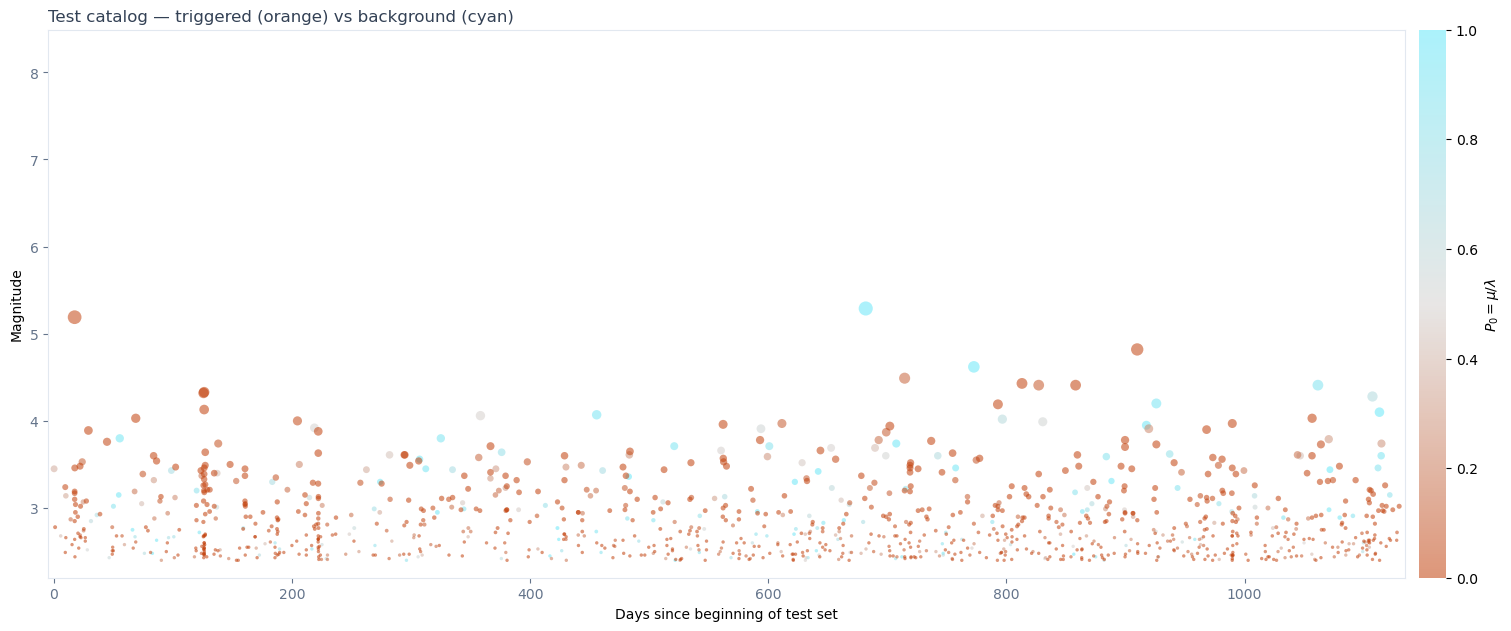

In [2]:
from matplotlib.colors import LinearSegmentedColormap, Normalize

bg_path = (
    ROOT / f"horizon_{HORIZON_DAYS:g}d" / "analysis_cache" / "background_probability.csv"
)
p0_frame = pd.read_csv(bg_path)
p0_obs = p0_frame.loc[p0_frame["source"] == "observed"].copy()
origin_days = float((test_start - pd.Timestamp("1970-01-01")) / pd.Timedelta("1D"))
p0_obs["days"] = p0_obs["time_days"] - origin_days
p0_obs = p0_obs.sort_values("p0", ascending=False)

trig_cmap = LinearSegmentedColormap.from_list(
    "triggered_background", ["#C2410C", "#D6D3D1", "#67E8F9"]
)

fig, ax = plt.subplots(figsize=(15, 6.2), constrained_layout=True)
ax.set_facecolor("white")
sizes = np.clip(14.0 * (p0_obs["magnitude"].to_numpy() - mc + 0.35) ** 1.7, 6.0, 180.0)
sc = ax.scatter(
    p0_obs["days"], p0_obs["magnitude"],
    c=p0_obs["p0"], cmap=trig_cmap, norm=Normalize(0.0, 1.0),
    s=sizes, alpha=0.55, linewidths=0, zorder=3,
)
y_top = float(p0_obs["magnitude"].max()) + 3.2
ax.set_ylim(float(p0_obs["magnitude"].min()) - 0.2, y_top)
ax.set_xlim(float(p0_obs["days"].min()) - 5, float(p0_obs["days"].max()) + 5)
ax.set_xlabel("Days since beginning of test set")
ax.set_ylabel("Magnitude")
ax.tick_params(colors="#64748B")
for spine in ax.spines.values():
    spine.set_color("#E2E8F0")
cbar = fig.colorbar(sc, ax=ax, pad=0.01, fraction=0.03)
cbar.set_label(r"$P_0 = \mu / \lambda$")
cbar.outline.set_visible(False)
ax.set_title("Test catalog — triggered (orange) vs background (cyan)", loc="left", color="#334155")
plt.show()


### One forecast, observed on top

A single ETAS seed from the analysis cache, drawn as pale dust. Observed test events sit on top, slightly stronger.


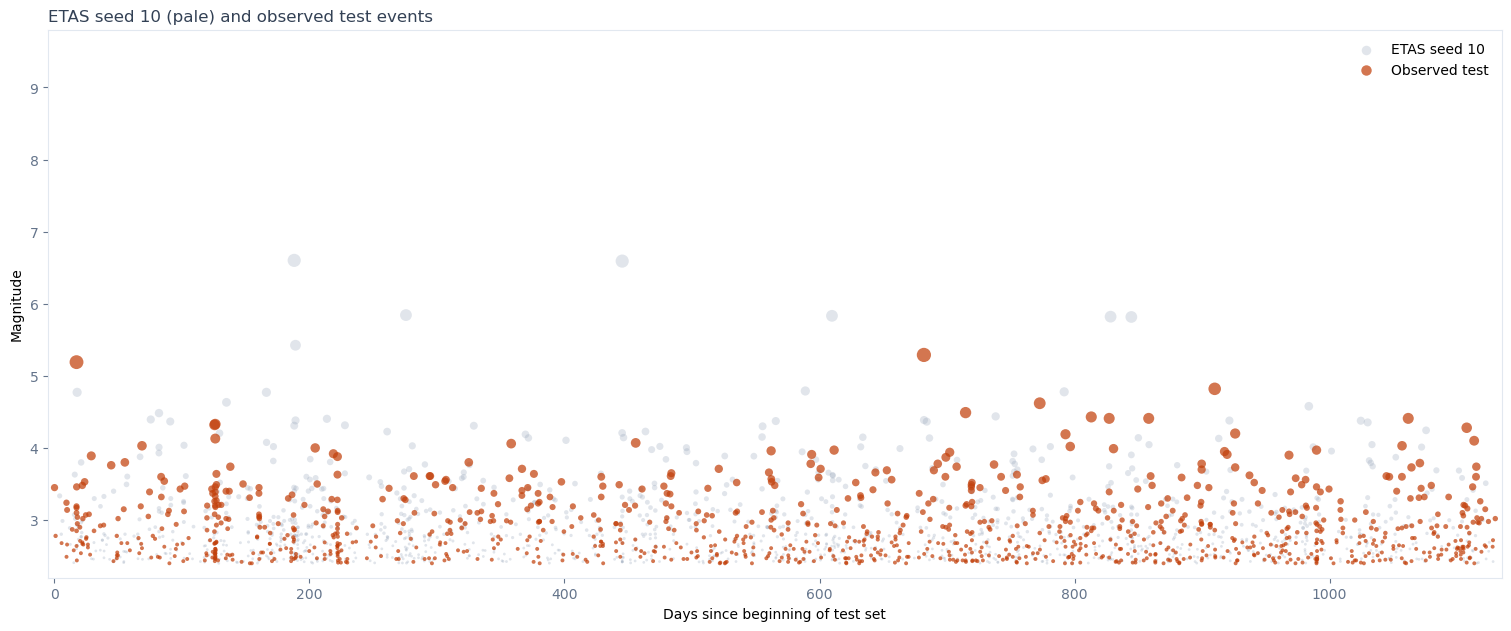

In [3]:
DECOR_SEED = 10

cache_events = ROOT / f"horizon_{HORIZON_DAYS:g}d" / "analysis_cache" / "events"
seed_npz = np.load(cache_events / "etas" / f"seed_{DECOR_SEED}.npz")
obs_npz = np.load(cache_events / "observed.npz")
origin_days = float((test_start - pd.Timestamp("1970-01-01")) / pd.Timedelta("1D"))

sim_days = seed_npz["time_days"] - origin_days
obs_days = obs_npz["time_days"] - origin_days
sim_mag = seed_npz["magnitude"]
obs_mag = obs_npz["magnitude"]

fig, ax = plt.subplots(figsize=(15, 6.2), constrained_layout=True)
ax.set_facecolor("white")
ax.scatter(
    sim_days, sim_mag,
    s=np.clip(10.0 * (sim_mag - mc + 0.3) ** 1.5, 4.0, 90.0),
    c="#94A3B8", alpha=0.28, linewidths=0, zorder=2,
    label=f"ETAS seed {DECOR_SEED}",
)
ax.scatter(
    obs_days, obs_mag,
    s=np.clip(16.0 * (obs_mag - mc + 0.35) ** 1.6, 8.0, 160.0),
    c="#C2410C", alpha=0.72, linewidths=0, zorder=4,
    label="Observed test",
)
mag_all = np.concatenate([sim_mag, obs_mag])
day_all = np.concatenate([sim_days, obs_days])
ax.set_ylim(float(mag_all.min()) - 0.2, float(mag_all.max()) + 3.2)
ax.set_xlim(float(day_all.min()) - 5, float(day_all.max()) + 5)
ax.set_xlabel("Days since beginning of test set")
ax.set_ylabel("Magnitude")
ax.tick_params(colors="#64748B")
for spine in ax.spines.values():
    spine.set_color("#E2E8F0")
ax.legend(frameon=False, loc="upper right")
ax.set_title(
    f"ETAS seed {DECOR_SEED} (pale) and observed test events",
    loc="left", color="#334155",
)
plt.show()


### Catalog map

Training and test earthquakes inside the Hauksson study polygon, sized by magnitude and washed out so a title can sit on the empty margin.


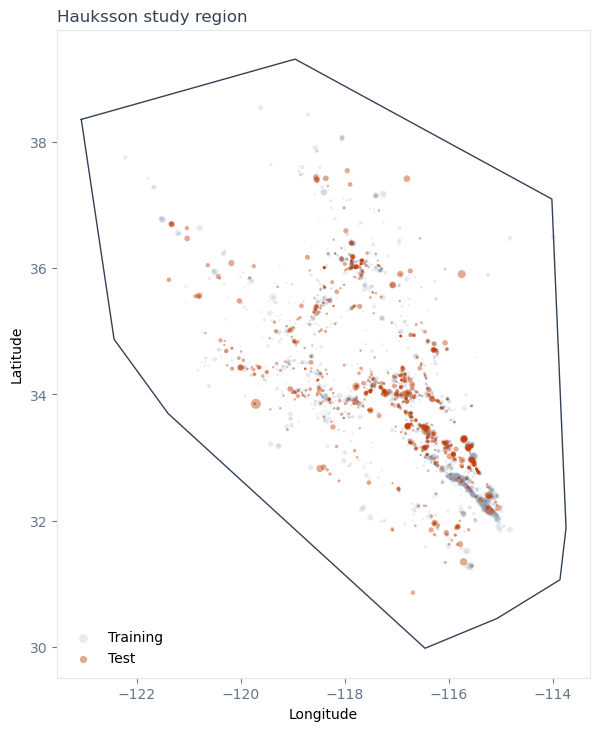

In [4]:
cache_events = ROOT / f"horizon_{HORIZON_DAYS:g}d" / "analysis_cache" / "events"
train_npz = np.load(cache_events / "training.npz")
obs_npz = np.load(cache_events / "observed.npz")
polygon = np.load(REPO_ROOT / cfg["shape_coords"])
if not np.allclose(polygon[0], polygon[-1]):
    polygon = np.vstack([polygon, polygon[:1]])

fig, ax = plt.subplots(figsize=(12, 7.2), constrained_layout=True)
ax.set_facecolor("white")
ax.scatter(
    train_npz["longitude"], train_npz["latitude"],
    s=np.clip(4.0 * (train_npz["magnitude"] - mc + 0.4) ** 1.8, 2.0, 80.0),
    c="#94A3B8", alpha=0.22, linewidths=0, zorder=2, label="Training",
)
ax.scatter(
    obs_npz["longitude"], obs_npz["latitude"],
    s=np.clip(6.0 * (obs_npz["magnitude"] - mc + 0.4) ** 1.8, 3.0, 120.0),
    c="#C2410C", alpha=0.45, linewidths=0, zorder=3, label="Test",
)
ax.plot(polygon[:, 1], polygon[:, 0], color="#334155", lw=1.0, zorder=4)
lat_mid = float(np.mean(polygon[:, 0]))
ax.set_aspect(1.0 / np.cos(np.deg2rad(lat_mid)))
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.tick_params(colors="#64748B")
for spine in ax.spines.values():
    spine.set_color("#E2E8F0")
ax.legend(frameon=False, loc="lower left")
ax.set_title("Hauksson study region", loc="left", color="#334155")
plt.show()
